# Reviewing ECMWF, ERA5 data for OND, JJAS and MAM

This notebook reviews the rainfall data for the 3 seasons and looks at the driest years to get years to calibrate the trigger against.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import ocha_stratus as stratus
from src.datasources.era5 import fetch_era5_data
from src.datasources.seas5 import fetch_seas5_data
from src.constants import *
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from affine import Affine
from rasterstats import zonal_stats
import calendar
import math

In [3]:
pd.options.display.float_format = "{:,.2f}".format

In [4]:
ond_blob_name = "ds-aa-eth-drought/exploration/Ethiopia OND zones.csv"
mam_blob_name = "ds-aa-eth-drought/exploration/Ethiopia MAM zones.csv"
jjas_blob_name = "ds-aa-eth-drought/exploration/Ethiopia JJAS zones.csv"
ond_validation_data = (
    "ds-aa-eth-drought/exploration/Ethiopia Drought Validation Data OND.csv"
)
mam_validation_data = (
    "ds-aa-eth-drought/exploration/Ethiopia Drought Validation Data MAM.csv"
)
jjas_validation_data = (
    "ds-aa-eth-drought/exploration/Ethiopia Drought Validation Data JJAS.csv"
)
# maproom hindcasts
somali_mam_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP Ethiopia AA MAM Trigger Documentation and Metrics - Somali Region.csv"
somali_ond_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP Ethiopia AA OND Trigger Documentation and Metrics - Somali Region.csv"
oromia_mam_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP FbF Ethiopia 2023 MAM Trigger Documentation and Metrics - Oromia Region.csv"
oromia_ond_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP AA Ethiopia OND Trigger Documentation and Metrics - Oromia Region (1).csv"
south_mam_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP Ethiopia AA MAM Trigger Documentation and Metrics - South Ethiopia Region.csv"
south_ond_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP AA Ethiopia OND Trigger Documentation and Metrics - South Ethiopia Region.csv"
start_date = pd.Timestamp("1997-01-01")
end_date = pd.Timestamp("2025-12-01")
ond_months = [10, 11, 12]
mam_months = [3, 4, 5]
jjas_months = [6, 7, 8, 9]

In [5]:
# plot the admin bounds for each season
eth_adm2 = stratus.codab.load_codab_from_fieldmaps("ETH", admin_level=2)
eth_adm1 = stratus.codab.load_codab_from_fieldmaps("ETH", admin_level=1)
eth_adm0 = stratus.codab.load_codab_from_fieldmaps("ETH", admin_level=0)

In [6]:
eth_adm2[eth_adm2["adm2_src"] == "ET1600"]

,fid,adm2_id,adm2_src,adm2_name,adm2_name1,adm2_name2,adm1_id,adm1_src,adm1_name,adm1_name1,...,region2_nm,region1_cd,region1_nm,status_cd,status_nm,wld_date,wld_update,wld_view,wld_notes,geometry
91,14133,ETH-20230404-13-01,ET1600,Sidama,None,None,ETH-20230404-13,ET16,Sidama,None,...,Sub-Saharan Africa,2,Africa,1,State,2025-02-24,2025-07-29,intl,None,"MULTIPOLYGON (((38.25519 6.45801, 38.25603 6.4..."


In [7]:
season_csv = stratus.load_csv_from_blob(
    mam_blob_name, stage="dev", container_name="projects"
)
seas5_data = fetch_seas5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data = fetch_era5_data(
    season_csv["adm2_pcode"].unique(), start_date=start_date, end_date=end_date
)
era5_data["year"] = pd.to_datetime(era5_data["valid_date"]).dt.year
era5_data["valid_month"] = pd.to_datetime(era5_data["valid_date"]).dt.month
era5_data["mean"] = era5_data["mean"] * era5_data["valid_month"].map(days_in_month)

# validation data (CERF + EMDAT)
validation_csv = stratus.load_csv_from_blob(
    mam_validation_data, stage="dev", container_name="projects"
)
validation_csv["year"] = validation_csv["Season"].str[-4:].astype(int)
season_months = [3, 4, 5]
lead_time_map = {11: 4, 12: 3, 1: 2, 2: 1}

In [8]:
df = seas5_data.copy()
all_years = list(range(1997, 2026))
df["issued_month"] = pd.to_datetime(df["issued_date"]).dt.month
df["valid_month"] = pd.to_datetime(df["valid_date"]).dt.month
df["valid_year"] = pd.to_datetime(df["valid_date"]).dt.year
df[
    (df["pcode"] == "ET1600")
    & (df["issued_month"] == 1)
    & (df["valid_month"].isin(season_months))
    & (df["valid_year"] == 2020)
]

,iso3,pcode,valid_date,issued_date,leadtime,adm_level,mean,median,min,max,count,sum,std,issued_month,valid_month,valid_year
15171,ETH,ET1600,2020-03-01,2020-01-01,2,2,2.14,2.13,1.14,2.77,219,468.29,0.44,1,3,2020
15419,ETH,ET1600,2020-04-01,2020-01-01,3,2,5.15,5.22,2.87,5.99,219,"1,128.21",1.02,1,4,2020
15729,ETH,ET1600,2020-05-01,2020-01-01,4,2,6.80,6.89,3.38,8.01,219,"1,489.87",1.38,1,5,2020


In [9]:
df = df[
    (df["valid_month"].isin(season_months))
    & (df["issued_month"].isin(lead_time_map.keys()))
].copy()
df["mean"] = df["mean"] * df["valid_month"].map(days_in_month)

In [10]:
df["valid_month"].unique()

array([5, 4, 3])

In [11]:
df[(df["pcode"] == "ET1600") & (df["valid_year"] == 2025) & (df["valid_month"] == 4)]

,iso3,pcode,valid_date,issued_date,leadtime,adm_level,mean,median,min,max,count,sum,std,issued_month,valid_month,valid_year
25652,ETH,ET1600,2025-04-01,2024-11-01,5,2,178.72,6.14,3.06,7.15,219,"1,304.67",1.31,11,4,2025
26196,ETH,ET1600,2025-04-01,2025-01-01,3,2,168.68,5.88,3.38,6.42,219,"1,231.34",1.02,1,4,2025
26568,ETH,ET1600,2025-04-01,2025-02-01,2,2,185.86,6.59,3.66,7.01,219,"1,356.75",1.12,2,4,2025
27326,ETH,ET1600,2025-04-01,2024-12-01,4,2,171.99,5.93,3.21,6.55,219,"1,255.56",1.09,12,4,2025


In [12]:
df = (
    df.groupby(["pcode", "valid_year", "issued_month"])["mean"]
    .sum()
    .reset_index()
    # .groupby(["valid_year", "issued_month"])["mean"]
    # .mean()
    # .reset_index()
)
df.tail()

,pcode,valid_year,issued_month,mean
7187,ET1600,2024,12,444.74
7188,ET1600,2025,1,443.61
7189,ET1600,2025,2,459.23
7190,ET1600,2025,11,438.23
7191,ET1600,2025,12,441.77


In [13]:
df["lead_time"] = df["issued_month"].map(lead_time_map)

df["rank"] = df.groupby(["pcode", "issued_month"])["mean"].rank(
    method="min", ascending=True
)
n = df["valid_year"].nunique()
df["return_period"] = ((n + 1) / df["rank"]).round(1)
df[(df["pcode"] == "ET1600") & (df["valid_year"] == 2020) & (df["issued_month"] == 1)]

,pcode,valid_year,issued_month,mean,lead_time,rank,return_period
7168,ET1600,2020,1,431.73,2,12.00,2.50


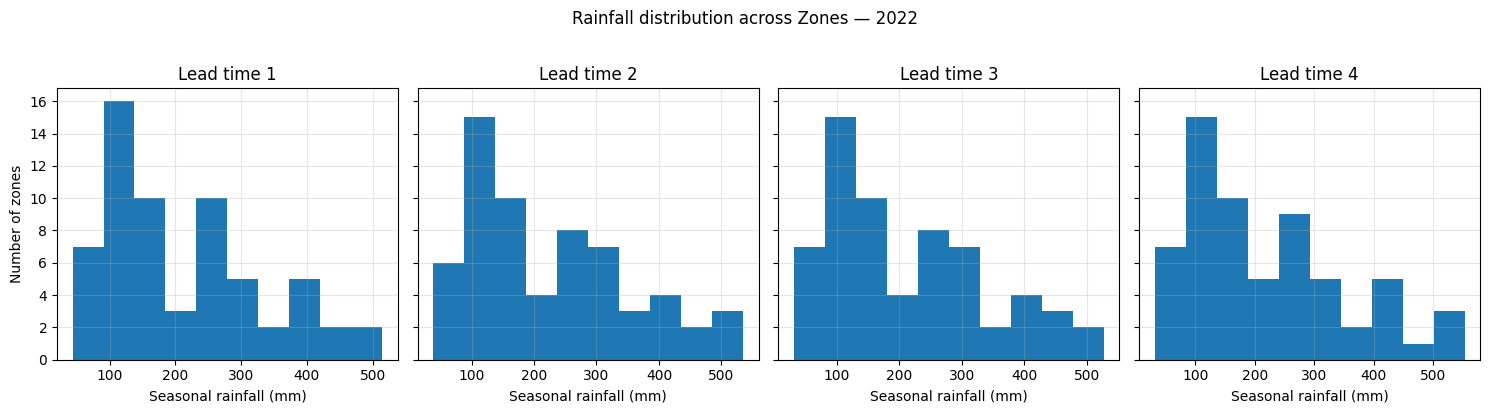

In [14]:
year = 2022
lead_times = df["lead_time"].sort_values().unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(lead_times),
    figsize=(15, 4),
    sharey=True,
)

if len(lead_times) == 1:
    axes = [axes]

for ax, lt in zip(axes, lead_times):

    df_lt = (
        df[(df["valid_year"] == year) & (df["lead_time"] == lt)]
        .groupby("pcode", as_index=False)["mean"]
        .mean()
    )

    df_lt = df_lt.sort_values("mean").reset_index(drop=True)
    pct = (df_lt.index + 1) / len(season_csv["adm2_pcode"].unique()) * 100

    ax.hist(
        df_lt["mean"],
        bins=10,
        density=False,
    )

    ax.set_title(f"Lead time {lt}")
    ax.set_xlabel("Seasonal rainfall (mm)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Number of zones")

fig.suptitle(f"Rainfall distribution across Zones — {year}", y=1.02)
plt.tight_layout()
plt.show()

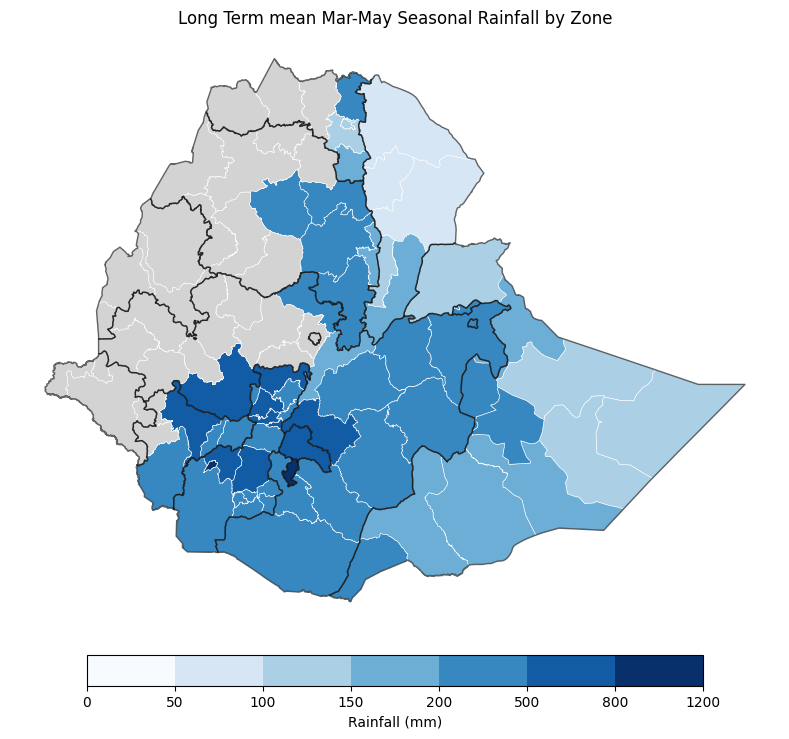

In [ ]:
era5_seas = era5_data[
    (era5_data["valid_month"].isin(season_months))
    & (era5_data["pcode"].isin(season_csv["adm2_pcode"].unique()))
].copy()
# sum grouping by pcode and year
era5_seas = (
    era5_seas.groupby(["pcode", "year"])["mean"]
    .sum()
    .groupby("pcode")
    .mean()
    .reset_index()
)
gdf = eth_adm2.merge(era5_seas, left_on="adm2_src", right_on="pcode", how="left")

# Define breaks
breaks = [0, 50, 100, 150, 200, 500, 800, 1200]  
labels = ["0–50", "50–100", "100–150", "150-200", "200–500", "500–800", "800+"]

cmap = mpl.cm.Blues
norm = mpl.colors.BoundaryNorm(breaks, cmap.N)

fig, ax = plt.subplots(figsize=(8, 9))

gdf.plot(
    column="mean",
    cmap=cmap,
    norm=norm,
    linewidth=0.4,
    edgecolor="white",
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    legend=True,
    legend_kwds={
        "label": "Rainfall (mm)",
        "orientation": "horizontal",
        "shrink": 0.8,
        "pad": 0.03,
    },
)
eth_adm1.boundary.plot(
    ax=ax,
    linewidth=1.0,
    edgecolor="black",
    alpha=0.6,
)
# Colorbar with breaks
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm._A = []


ax.set_title("Long Term mean Mar-May Seasonal Rainfall by Zone", fontsize=12)
ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
era5_median = era5_data[(era5_data["valid_month"].isin(season_months))]
era5_median = (
    era5_median.groupby(["pcode", "year"])["mean"]
    .sum()
    .reset_index()
    .groupby("year")["mean"]
    .mean()
    .reset_index()
)

era5_median.head()

,year,mean
0,1997,393.29
1,1998,307.05
2,1999,312.17
3,2000,240.96
4,2001,365.98


In [17]:
df_med = (
    df.groupby(["valid_year", "lead_time"])["mean"]
    .mean()
    .reset_index(name="median_rainfall")
)
df_wide = df_med.pivot(
    index="valid_year",
    columns="lead_time",
    values="median_rainfall",
)
df_wide["era5_median"] = df_wide.index.map(era5_median.set_index("year")["mean"])
# number of years (used for RP)
n_years = df_wide.shape[0]


def compute_rp(series):
    r = series.rank(method="min", ascending=True)  # driest = rank 1
    return (n_years + 1) / r


# compute RP columns
rp_cols = {}

for c in df_wide.columns:
    rp_cols[f"RP_{c}"] = compute_rp(df_wide[c])

df_rp = pd.DataFrame(rp_cols, index=df_wide.index)

# combine rainfall + return periods
df_out = pd.concat([df_wide, df_rp], axis=1)

# sort by ERA5 dryness (driest first)
df_out = df_out.sort_values("era5_median")

df_out.head(7)

,1,2,3,4,era5_median,RP_1,RP_2,RP_3,RP_4,RP_era5_median
valid_year,,,,,,,,,,
2022,212.53,224.97,211.57,220.51,192.11,3.00,1.20,1.30,1.43,30.00
2009,195.66,215.75,192.40,217.89,233.48,15.00,1.58,4.29,1.67,15.00
2000,199.16,219.66,197.40,206.19,240.96,10.00,1.36,3.33,2.73,10.00
2008,211.84,207.34,202.61,202.51,246.95,3.33,2.50,2.73,5.00,7.50
2021,207.12,195.58,189.24,207.41,276.36,7.50,15.00,7.50,2.50,6.00
2011,249.22,209.86,204.99,200.23,286.18,1.07,2.14,2.00,7.50,5.00
2012,211.24,201.64,208.44,205.53,288.37,3.75,5.00,1.88,3.00,4.29


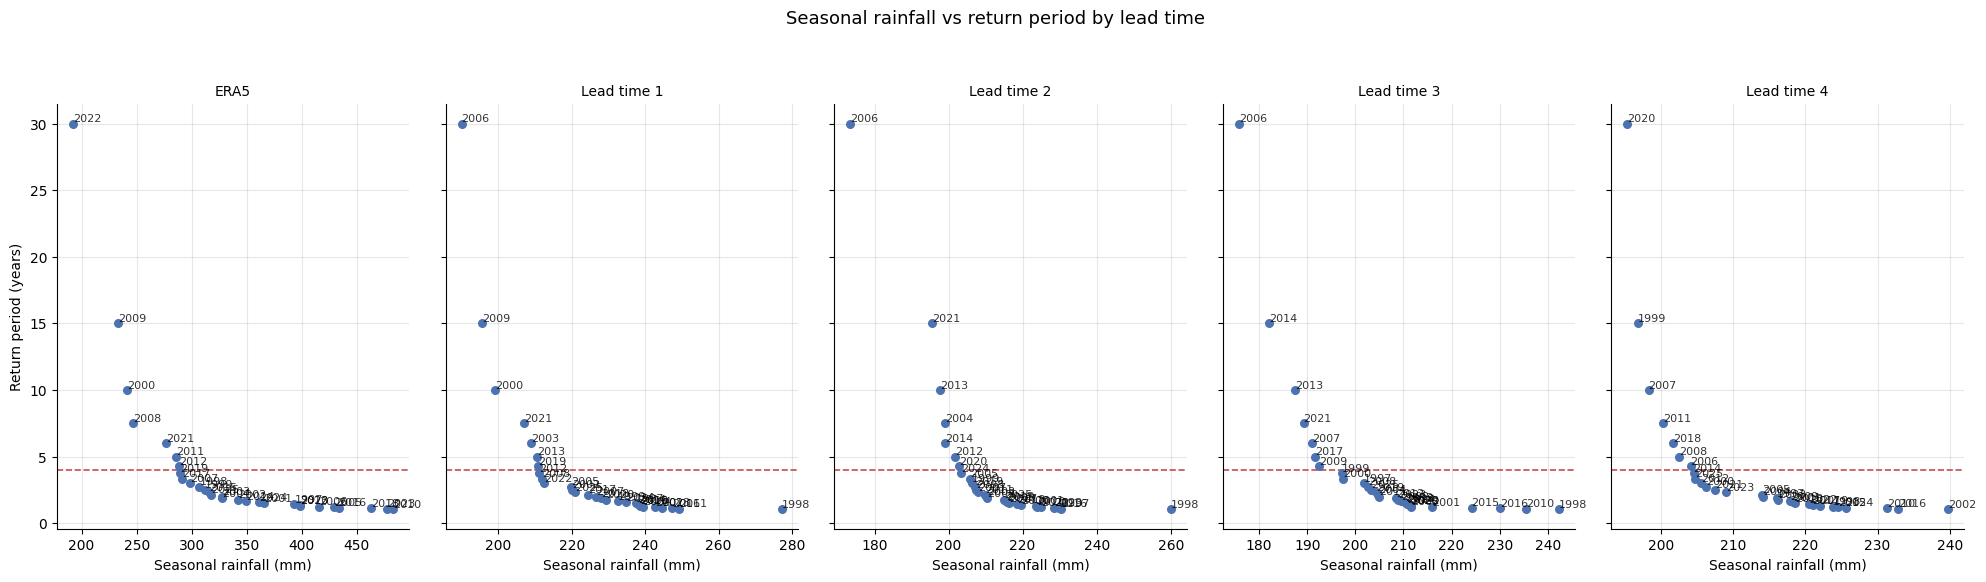

In [18]:
lead_times = [0, 1, 2, 3, 4]  # adjust if needed
n = len(lead_times)

fig, axes = plt.subplots(nrows=1, ncols=n, figsize=(4 * n, 5.5), sharey=True)

if n == 1:
    axes = [axes]

for ax, lt in zip(axes, lead_times):

    if lt == 0:
        x = df_out["era5_median"]
        y = df_out["RP_era5_median"]
        title = "ERA5"
    else:
        x = df_out[lt]
        y = df_out[f"RP_{lt}"]
        title = f"Lead time {lt}"

    d = pd.DataFrame({"x": x, "y": y}).dropna().sort_values("x")

    ax.scatter(
        d["x"],
        d["y"],
        s=30,
        color="#4C72B0",
        zorder=3,
    )

    # annotate years
    for year, row in d.iterrows():
        ax.text(
            row["x"],
            row["y"],
            str(year),
            fontsize=8,
            ha="left",
            va="bottom",
            alpha=0.8,
        )

    ax.axhline(4, color="#C44E52", linestyle="--", linewidth=1.2)
    ax.set_title(title, fontsize=10)

    ax.set_xlabel("Seasonal rainfall (mm)")
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Return period (years)")

fig.suptitle(
    "Seasonal rainfall vs return period by lead time",
    fontsize=13,
    y=1.05,
)

plt.tight_layout()
plt.show()

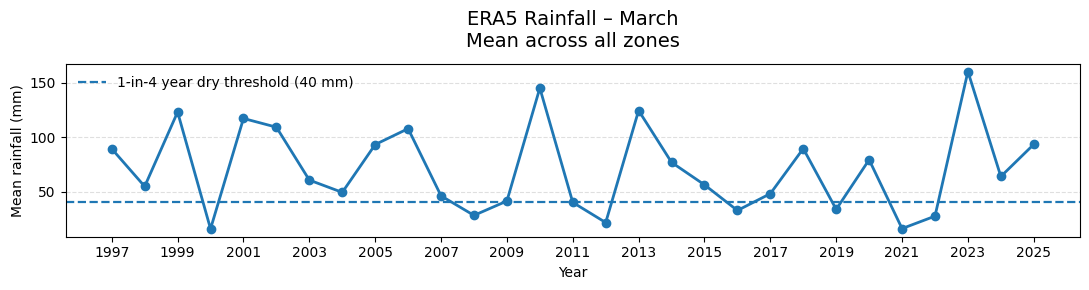

In [19]:
# ERA5 – March (monthly mean across zones)
df_plot = (
    era5_data[era5_data["valid_month"] == 3]
    .groupby("year", as_index=False)["mean"]
    .mean()
)

# 1-in-4 year dry threshold (25th percentile)
threshold_1in4 = df_plot["mean"].quantile(0.25)

fig, ax = plt.subplots(figsize=(11, 3))

ax.plot(
    df_plot["year"],
    df_plot["mean"],
    marker="o",
    linewidth=2,
)

ax.axhline(
    threshold_1in4,
    linestyle="--",
    linewidth=1.6,
    label=f"1-in-4 year dry threshold ({threshold_1in4:.0f} mm)",
)

ax.set_title(
    "ERA5 Rainfall – March\nMean across all zones",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("Year")
ax.set_ylabel("Mean rainfall (mm)")

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

ax.legend(frameon=False)
ax.set_xticks(df_plot["year"][::2])

plt.tight_layout()
plt.show()

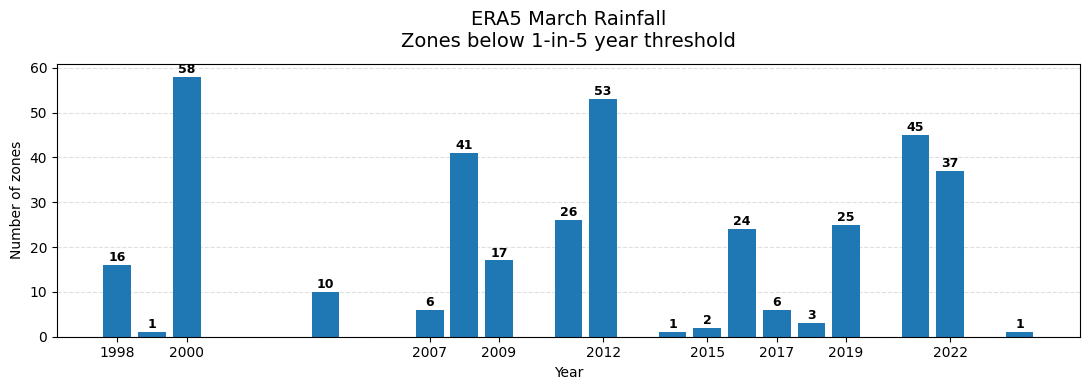

In [20]:
# March data, zone-level monthly means (one value per pcode-year)
df_zone = (
    era5_data[era5_data["valid_month"] == 3]
    .groupby(["year", "pcode"], as_index=False)["mean"]
    .mean()
)

# PER-ZONE return period (rank within each pcode) — this is the fix
df_zone["rank"] = df_zone.groupby("pcode")["mean"].rank(method="min", ascending=True)
n_years = df_zone["year"].nunique()
df_zone["return_period"] = ((n_years + 1) / df_zone["rank"]).round(1)

# count zones crossing 1-in-5 (RP >= 5) per year
zones_below_1in5 = (
    df_zone[df_zone["return_period"] >= 5]
    .groupby("year")
    .size()
    .reset_index(name="n_zones_below_1in5")
)
fig, ax = plt.subplots(figsize=(11, 4))

bars = ax.bar(
    zones_below_1in5["year"],
    zones_below_1in5["n_zones_below_1in5"],
    width=0.8,
)

# value labels
for rect in bars:
    h = rect.get_height()
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        h + 0.2,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "ERA5 March Rainfall\nZones below 1-in-5 year threshold",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("Year")
ax.set_ylabel("Number of zones")

ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.set_xticks(zones_below_1in5["year"][::2])

plt.tight_layout()
plt.show()

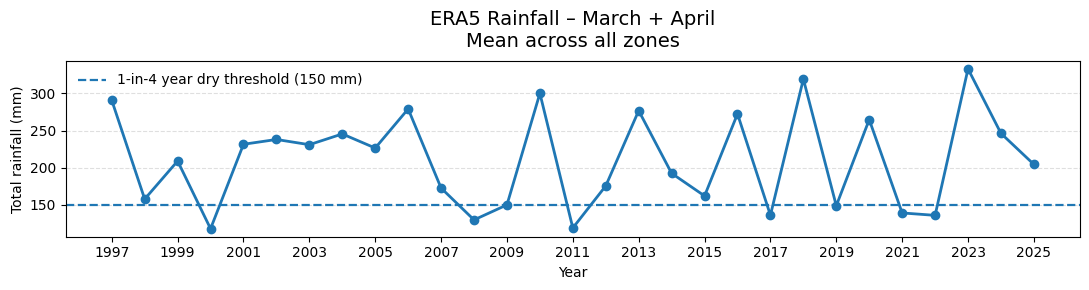

In [21]:
# Sum March + April rainfall per year (mean across zones first)
df_plot = (
    era5_data[era5_data["valid_month"].isin([3, 4])]
    .groupby(["year", "valid_month"], as_index=False)["mean"]
    .mean()
    .groupby("year", as_index=False)["mean"]
    .sum()
)

# 1-in-4 year dry threshold on the summed rainfall
threshold_1in4 = df_plot["mean"].quantile(0.25)

fig, ax = plt.subplots(figsize=(11, 3))

ax.plot(
    df_plot["year"],
    df_plot["mean"],
    marker="o",
    linewidth=2,
)

ax.axhline(
    threshold_1in4,
    linestyle="--",
    linewidth=1.6,
    label=f"1-in-4 year dry threshold ({threshold_1in4:.0f} mm)",
)

ax.set_title(
    "ERA5 Rainfall – March + April\nMean across all zones",
    fontsize=14,
    pad=10,
)
ax.set_xlabel("Year")
ax.set_ylabel("Total rainfall (mm)")

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

ax.legend(frameon=False)
ax.set_xticks(df_plot["year"][::2])

plt.tight_layout()
plt.show()

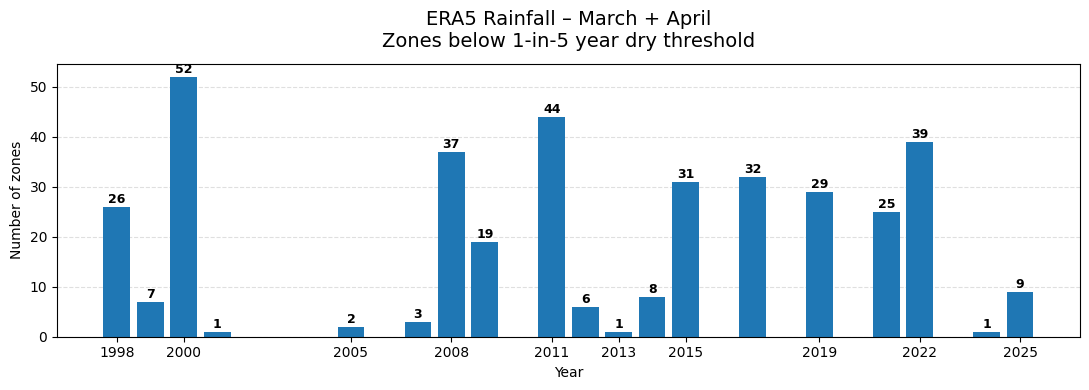

In [22]:
# March + April data, zone-level monthly means summed per year
df_zone = (
    era5_data[era5_data["valid_month"].isin([3, 4])]
    .groupby(["year", "pcode", "valid_month"], as_index=False)["mean"]
    .mean()
    .groupby(["year", "pcode"], as_index=False)["mean"]
    .sum()
)

# PER-ZONE return period (rank within each pcode)
df_zone["rank"] = df_zone.groupby("pcode")["mean"].rank(method="min", ascending=True)

n_years = df_zone["year"].nunique()
df_zone["return_period"] = ((n_years + 1) / df_zone["rank"]).round(1)

# count zones crossing 1-in-5 (RP >= 5) per year
zones_below_1in5 = (
    df_zone[df_zone["return_period"] >= 5]
    .groupby("year")
    .size()
    .reset_index(name="n_zones_below_1in5")
)

fig, ax = plt.subplots(figsize=(11, 4))

bars = ax.bar(
    zones_below_1in5["year"],
    zones_below_1in5["n_zones_below_1in5"],
    width=0.8,
)

# value labels
for rect in bars:
    h = rect.get_height()
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        h + 0.2,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "ERA5 Rainfall – March + April\nZones below 1-in-5 year dry threshold",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("Year")
ax.set_ylabel("Number of zones")

ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_xticks(zones_below_1in5["year"][::2])

plt.tight_layout()
plt.show()